<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Rainfall Forecast (Next 12 Months)
113    739.809323
114    539.585846
115    683.210418
116    537.790512
117    264.701323
118    171.667901
119    282.472670
120    360.181518
121    427.683590
122    796.752169
123    551.737486
124    586.303719
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


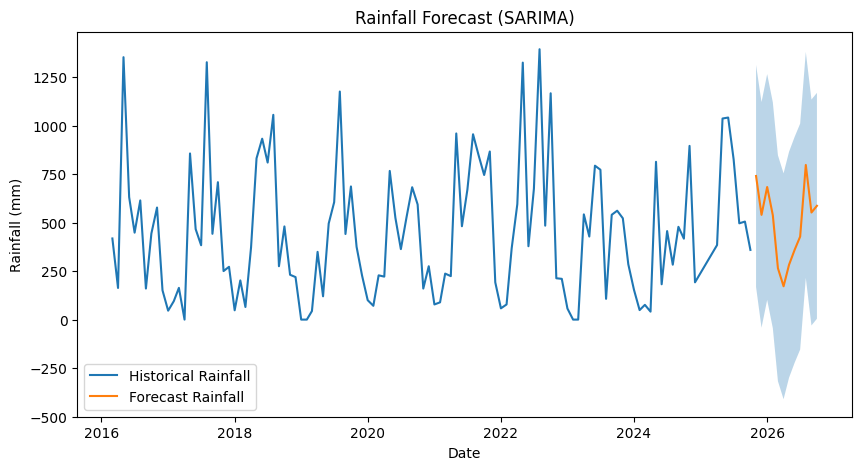

In [8]:
# ==========================================================
# Rainfall Forecasting using SARIMA
# ==========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# prepare rainfall time series
rain_series = rainfall.set_index("Date")["Rainfall"]

# train SARIMA model
sarima_model = SARIMAX(
    rain_series,
    order=(1,1,1),           # ARIMA parameters
    seasonal_order=(1,1,1,12) # 12 months seasonality
)

sarima_results = sarima_model.fit()

# forecast next 12 months
forecast = sarima_results.get_forecast(steps=12)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("\nRainfall Forecast (Next 12 Months)")
print(forecast_mean)

# ==========================================================
# Visualization
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(rain_series, label="Historical Rainfall")

future_dates = pd.date_range(
    start=rain_series.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.plot(future_dates, forecast_mean, label="Forecast Rainfall")

plt.fill_between(
    future_dates,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.3
)

plt.title("Rainfall Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()

plt.show()